In [1]:
import numpy as np
import pandas as pd
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf
import sklearn
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

# Attempt to import TensorFlow Addons; if unavailable, fall back to standard Adam optimizer.
try:
    import tensorflow_addons as tfa

    _has_tfa = True
except Exception:
    _has_tfa = False
    tfa = None




2026-05-05 08:08:51.669562: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777968531.682886      55 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777968531.687028      55 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-05 08:08:51.703970: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
class Config:
    image_size = 128
    input_shape = [image_size, image_size, 3]
    learning_rate = 0.001
    weight_decay = 0.0001
    batch_size = 128
    num_classes = 1
    num_epochs = 30
    patch_size = 16
    num_patches = (image_size // patch_size) ** 2
    projection_dim = 64
    num_heads = 4
    transformer_units = [projection_dim * 2, projection_dim]
    transformer_layers = 8
    mlp_head_units = [2048, 1024]




In [3]:
def sample_images(images, row_count, column_count):
    fig, axs = plt.subplots(row_count, column_count, figsize=(10, 10))
    for i in range(row_count):
        for j in range(column_count):
            axs[i, j].imshow(images[i * column_count + j])
            axs[i, j].axis("off")
    plt.show()




In [4]:
train = pd.read_csv("../input/petfinder-pawpularity-score/train.csv")
test = pd.read_csv("../input/petfinder-pawpularity-score/test.csv")
sample_submission = pd.read_csv(
    "../input/petfinder-pawpularity-score/sample_submission.csv"
)



In [5]:
train.head()



,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur,Pawpularity
0,1a8795e64a294ed0c95132e18ee198e1,0,1,1,1,0,0,0,0,0,0,0,0,55
1,08ce774252e822838bf598aa10518a11,0,1,1,1,0,0,0,0,0,0,0,0,100
2,a71c677d87606a56160b70c5f6fa4526,0,1,1,0,0,0,0,0,0,0,0,0,27
3,11d5914ad80403375c8e0ccd959fc08e,0,1,1,1,0,0,0,0,0,0,0,0,51
4,c04034bbfe0a0d89729541c2271a674e,0,1,1,1,0,0,0,0,0,0,0,0,48


In [6]:
train["file_path"] = train["Id"].apply(
    lambda identifier: "../input/petfinder-pawpularity-score/train/"
    + identifier
    + ".jpg"
)
test["file_path"] = test["Id"].apply(
    lambda identifier: "../input/petfinder-pawpularity-score/test/"
    + identifier
    + ".jpg"
)



In [7]:
train.head()



,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur,Pawpularity,file_path
0,1a8795e64a294ed0c95132e18ee198e1,0,1,1,1,0,0,0,0,0,0,0,0,55,../input/petfinder-pawpularity-score/train/1a8...
1,08ce774252e822838bf598aa10518a11,0,1,1,1,0,0,0,0,0,0,0,0,100,../input/petfinder-pawpularity-score/train/08c...
2,a71c677d87606a56160b70c5f6fa4526,0,1,1,0,0,0,0,0,0,0,0,0,27,../input/petfinder-pawpularity-score/train/a71...
3,11d5914ad80403375c8e0ccd959fc08e,0,1,1,1,0,0,0,0,0,0,0,0,51,../input/petfinder-pawpularity-score/train/11d...
4,c04034bbfe0a0d89729541c2271a674e,0,1,1,1,0,0,0,0,0,0,0,0,48,../input/petfinder-pawpularity-score/train/c04...


<Axes: >

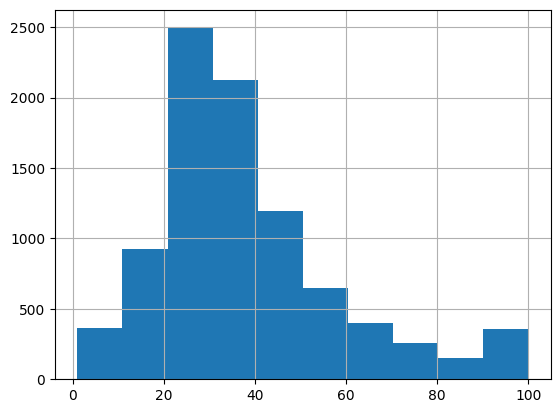

In [8]:
train["Pawpularity"].hist()



In [9]:
tabular_columns = [
    "Subject Focus",
    "Eyes",
    "Face",
    "Near",
    "Action",
    "Accessory",
    "Group",
    "Collage",
    "Human",
    "Occlusion",
    "Info",
    "Blur",
]




In [10]:
def preprocess_image(image_url):
    image_string = tf.io.read_file(image_url)
    image = tf.image.decode_jpeg(image_string, channels=3)
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.central_crop(image, 1.0)
    image = tf.image.resize(image, (Config.image_size, Config.image_size))
    return image




In [11]:
def preprocess(image_url, tabular):
    image = preprocess_image(image_url)
    return (image, tabular[1:]), tabular[0]




In [12]:
augmentation_layer = keras.Sequential(
    [
        keras.layers.Input(Config.input_shape),
        layers.RandomRotation(factor=0.02),
        layers.RandomZoom(height_factor=0.2, width_factor=0.2),
    ]
)




2026-05-05 08:08:58.453564: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1777968538.454005      55 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:06:00.0, compute capability: 8.6


In [13]:
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x




In [14]:
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super(Patches, self).__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches




(128, 128, 3)
(1, 128, 128, 3)
Image size: 128 X 128
Patch size: 16 X 16
Patches per image: 64
Elements per patch: 768


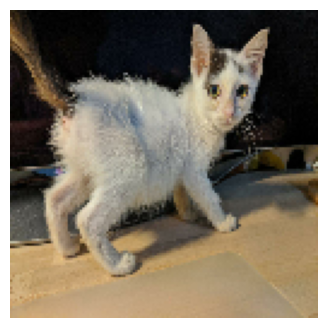

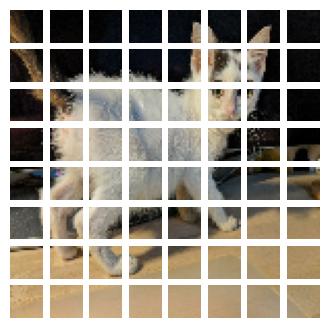

In [15]:
index = np.random.choice(train.shape[0])
plt.figure(figsize=(4, 4))
image = preprocess_image(tf.constant(train.iloc[index]["file_path"], dtype=tf.string))
print(image.shape)
plt.imshow(np.squeeze(image))
plt.axis("off")

resized_image = tf.image.resize(
    tf.convert_to_tensor([image]), size=(Config.image_size, Config.image_size)
)
print(resized_image.shape)
patches = Patches(Config.patch_size)(resized_image)
print(f"Image size: {Config.image_size} X {Config.image_size}")
print(f"Patch size: {Config.patch_size} X {Config.patch_size}")
print(f"Patches per image: {patches.shape[1]}")
print(f"Elements per patch: {patches.shape[-1]}")

n = int(np.sqrt(patches.shape[1]))
plt.figure(figsize=(4, 4))
for i, patch in enumerate(patches[0]):
    ax = plt.subplot(n, n, i + 1)
    patch_img = tf.reshape(patch, (Config.patch_size, Config.patch_size, 3))
    plt.imshow(patch_img.numpy())
    plt.axis("off")




In [16]:
class PatchEncoder(layers.Layer):

    def __init__(self, num_patches, projection_dim):
        super(PatchEncoder, self).__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded




In [17]:
def create_vision_transformer(use_tabular_inputs=False):

    tabular_inputs = tf.keras.Input(shape=(len(tabular_columns),))
    inputs = layers.Input(shape=Config.input_shape)
    augmented = augmentation_layer(inputs)
    patches = Patches(Config.patch_size)(augmented)
    encoder_patches = PatchEncoder(Config.num_patches, Config.projection_dim)(patches)

    for _ in range(Config.transformer_layers):
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoder_patches)
        attention_output = layers.MultiHeadAttention(
            num_heads=Config.num_heads, key_dim=Config.projection_dim, dropout=0.1
        )(x1, x1)
        x2 = layers.Add()([attention_output, encoder_patches])

        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        x3 = mlp(x3, hidden_units=Config.transformer_units, dropout_rate=0.1)
        encoder_patches = layers.Add()([x3, x2])

    representation = layers.LayerNormalization(epsilon=1e-6)(encoder_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.5)(representation)

    features = mlp(representation, hidden_units=Config.mlp_head_units, dropout_rate=0.5)

    if use_tabular_inputs:
        image_x = layers.Dense(128, activation=tf.nn.gelu)(features)
        tabular_x = mlp(tabular_inputs, hidden_units=[16] * 10, dropout_rate=0.5)
        x = tf.keras.layers.Concatenate(axis=1)([image_x, tabular_x])
    else:
        x = features

    outputs = layers.Dense(1)(x)

    model = keras.Model(inputs=[inputs, tabular_inputs], outputs=outputs)
    return model




In [18]:
model = create_vision_transformer(True)
tf.keras.utils.plot_model(model, show_shapes=True)



In [19]:
image = np.random.normal(size=(1, Config.image_size, Config.image_size, 3)).astype(
    np.float32
)
tabular = np.random.normal(size=(1, len(tabular_columns))).astype(np.float32)
print(image.shape, tabular.shape)
print(model((image, tabular)).shape)



(1, 128, 128, 3) (1, 12)
(1, 1)


In [20]:
tf.keras.backend.clear_session()
models = []
historys = []
kfold = KFold(n_splits=5, shuffle=True, random_state=997)
train_best_fold = True
best_fold = 4
for index, (train_indices, val_indices) in enumerate(kfold.split(train)):
    if train_best_fold and index != best_fold:
        continue
    x_train = train.loc[train_indices, "file_path"]
    tabular_train = train.loc[train_indices, ["Pawpularity"] + tabular_columns]
    x_val = train.loc[val_indices, "file_path"]
    tabular_val = train.loc[val_indices, ["Pawpularity"] + tabular_columns]
    checkpoint_path = f"model_{index}.weights.h5"  # must end with .weights.h5
    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path, save_best_only=True, save_weights_only=True
    )
    early_stop = tf.keras.callbacks.EarlyStopping(min_delta=1e-4, patience=10)
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        factor=0.3, patience=2, min_lr=1e-7
    )
    callbacks = [early_stop, checkpoint, reduce_lr]

    loss = tf.keras.losses.MeanSquaredError()

    # Use AdamW if TensorFlow Addons is available; otherwise fall back to standard Adam.
    if _has_tfa:
        optimizer = tfa.optimizers.AdamW(
            learning_rate=Config.learning_rate, weight_decay=Config.weight_decay
        )
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate=Config.learning_rate)

    train_ds = (
        tf.data.Dataset.from_tensor_slices((x_train, tabular_train))
        .map(preprocess)
        .shuffle(512)
        .batch(Config.batch_size)
        .cache()
        .prefetch(1)
    )
    val_ds = (
        tf.data.Dataset.from_tensor_slices((x_val, tabular_val))
        .map(preprocess)
        .batch(Config.batch_size)
        .cache()
        .prefetch(1)
    )
    model = create_vision_transformer(use_tabular_inputs=True)
    model.compile(
        loss=loss,
        optimizer=optimizer,
        metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse"), "mae", "mape"],
    )
    history = model.fit(
        train_ds,
        epochs=Config.num_epochs,
        validation_data=val_ds,
        callbacks=callbacks,
        verbose=0,
    )
    model.load_weights(checkpoint_path)
    historys.append(history)
    models.append(model)




In [21]:
def preprocess_test_data(image_url, tabular):
    image = preprocess_image(image_url)
    return (image, tabular), 0




In [22]:
test_ds = (
    tf.data.Dataset.from_tensor_slices((test["file_path"], test[tabular_columns]))
    .map(preprocess_test_data)
    .batch(Config.batch_size)
    .cache()
    .prefetch(1)
)



In [23]:
use_best_result = True
if use_best_result:
    if train_best_fold:
        best_model = models[0]  # only the selected best fold was trained
    else:
        best_score = float("inf")
        best_idx = 0
        for fold, history in enumerate(historys):
            for val_rmse in history.history["val_rmse"]:
                if val_rmse < best_score:
                    best_score = val_rmse
                    best_idx = fold
        best_model = models[best_idx]
    preds = best_model.predict(test_ds).reshape(-1)
    sample_submission["Pawpularity"] = preds
    sample_submission.to_csv("submission.csv", index=False)
else:
    total_results = []
    for m in models:
        total_results.append(m.predict(test_ds).reshape(-1))
    results = np.mean(total_results, axis=0)
    sample_submission["Pawpularity"] = results
    sample_submission.to_csv("submission.csv", index=False)

8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 656ms/step
